In [1]:
"""
Gradient Frequency Neural Network (GFNN) Oscillator
====================================================
Implements the nonlinear oscillator:

    (1/f_i) ż_i = z_i (α + i2πr + β₁|z_i|² + εβ₂|z_i|⁴ / (1 − ε|z_i|²)) + x

Gradient Frequency Neural Network (GFNN) Oscillator
====================================================
Implements the nonlinear oscillator:

    (1/f_i) ż_i = z_i (α + i2πr + β₁|z_i|² + εβ₂|z_i|⁴ / (1 − ε|z_i|²)) + x

Integrated via RK4 over a bank of oscillators at user-defined frequencies.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import os
from pathlib import Path 
from scipy.io import loadmat
from scipy.signal import resample

import mne
from mne import find_events
from mne.channels import make_dig_montage
import eelbrain
import pickle

BASE_DIR = Path('NRT').resolve().parent  # TRF/

# Define the dataset root; replace it with the proper path if you downloaded the dataset in a different location
DATA_ROOT = BASE_DIR / '../TRF/liberi_dataset/doi_10_5061_dryad_g1jwstqmh__v20211008'

# Define paths that will be used throughout
WAV_DIR = DATA_ROOT / 'diliBach_wav_4dryad'

STIMULUS_DIR = DATA_ROOT / 'diliBach_wav_4dryad'
EEG_DIR = DATA_ROOT / 'diliBach_4dryad_CND'
print(EEG_DIR)

LOW_FREQUENCY = 1
HIGH_FREQUENCY = 8

SUBJECTS = [
    'Sub1',
    'Sub2',
    'Sub3',
    'Sub4',
    'Sub5',
    'Sub6',
    'Sub7',
    'Sub8',
    'Sub9',
    'Sub10',
    'Sub11',
    'Sub12',
    'Sub13',
    'Sub14',
    'Sub15',
    'Sub16', 
    'Sub17', 
    'Sub18', 
    'Sub19', 
    'Sub20'
    ]

SUBJECT = 'Sub19'


/Users/arianapereira/Documents/Masters/Projects/SigMA/musical-surprisal/NRT/../TRF/liberi_dataset/doi_10_5061_dryad_g1jwstqmh__v20211008/diliBach_4dryad_CND


In [2]:
# Load EEG data from one subject
def load_subject_raw_eeg(filepath, subject):
    
    # Extract subject index from string (e.g., 'S18' -> 18)
    subject_idx = int(subject[3:])
        
    # Load the .mat file
    mat_data = loadmat(filepath, struct_as_record=False, squeeze_me=True)
    eeg = mat_data["eeg"]
    target_fs = 100  # Target sampling frequency
    orig_fs = int(eeg.fs)
    resample_needed = orig_fs != target_fs
    for i in range(len(eeg.data)):
        
        # Scale data 
        trial_data = 100 * eeg.data[i].astype(np.float32) / np.iinfo(np.int32).max
        
        # Resample to 500Hz, to be consistent with Alice
        if resample_needed:
            n_samples = int(trial_data.shape[0] * target_fs / orig_fs)
            trial_data = resample(trial_data, n_samples, axis=0)
        
        eeg.data[i] = trial_data
        
    # Extract key information into a dictionary
    raw_data = {
        'trials': eeg.data,
        'fs': target_fs,
        'chanlocs': eeg.chanlocs,
        'pad_start': int(eeg.paddingStartSample * target_fs / orig_fs) if resample_needed else int(eeg.paddingStartSample),
        'subject_type': 'Musician' if subject_idx >= 11 else 'Non-musician'
    }
    
    print(f"✓ Loaded {raw_data['subject_type']} (Subject {subject})")
    print(f"  - {len(raw_data['trials'])} trials, {raw_data['trials'][0].shape[1]} channels")
    
    return raw_data


def create_mne_raw_from_loaded(subject_data):
    """Convert already-loaded Bach data to MNE Raw object with channel positions."""
    
    trials = subject_data['trials']
    sfreq = subject_data['fs']
    pad_start = subject_data['pad_start']    
    chanlocs = subject_data['chanlocs']
    
    # Get channel names and positions
    ch_names = []
    positions = []
    
    for ch in chanlocs:
        
        # Get channel label        
        ch_names.append(ch.labels)
        
        # Get channel positions if available
        if hasattr(ch, 'X') and hasattr(ch, 'Y') and hasattr(ch, 'Z'):
            positions.append([ch.Y, ch.X, ch.Z])
    
    # Concatenate all trials
    all_trials = []
    trial_lengths = []
    
    for trial in trials:
        # Remove padding and transpose to channels x time
        trial_clean = trial[pad_start:, :].T
        all_trials.append(trial_clean)
        trial_lengths.append(trial_clean.shape[1])
    
    # Concatenate
    eeg_continuous = np.hstack(all_trials)
    n_channels, n_samples = eeg_continuous.shape
    
    # Create stimulus channel with trial markers
    stim_data = np.zeros((1, n_samples))
    
    # Mark all 30 trial onsets
    current_sample = 0
    marker_positions = []
    for i in range(30):
        # Place marker at current position (offset by 1 if at sample 0)
        marker_sample = 1 if current_sample == 0 else current_sample
        stim_data[0, marker_sample] = i + 1  # Use 1-30 as event IDs
        marker_positions.append((i+1, marker_sample))
        current_sample += trial_lengths[i]  # Move to next trial start
        
    # Combine EEG and stim
    data_with_stim = np.vstack([eeg_continuous, stim_data])
    
    # Channel setup
    ch_names = ch_names + ['STI']
    ch_types = ['eeg'] * n_channels + ['stim']
    
    # Create Raw
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
    raw = mne.io.RawArray(data_with_stim, info)
        
    montage = make_dig_montage(
        ch_pos=dict(zip(ch_names[:n_channels], positions)),
        coord_frame='head'
    )
    raw.set_montage(montage)
    return raw


def create_eelbrain_events(raw):
    """Create eelbrain events with correct column structure."""
    
    # Find events in the MNE raw object
    mne_events = mne.find_events(raw, stim_channel='STI', verbose=False)
    
    # Create eelbrain Dataset with the required columns
    events_data = {
        'i_start': mne_events[:, 0],  # Sample indices
        'trigger': mne_events[:, 2],  # Event IDs (1-30)
        'event': mne_events[:, 2]     # Same as trigger (1-30)
    }
    
    events = eelbrain.Dataset(events_data)

    # Link raw data to events for use in variable_length_epochs
    events.info['raw'] = raw
    return events

In [3]:

# Main execution
eeg_data = load_subject_raw_eeg(EEG_DIR / f'data{SUBJECT}.mat', SUBJECT)
raw = create_mne_raw_from_loaded(eeg_data)

# Filter the raw data to the desired band
raw.filter(LOW_FREQUENCY, HIGH_FREQUENCY, n_jobs=1)

# Create events with correct structure
events = create_eelbrain_events(raw)
events


✓ Loaded Musician (Subject Sub19)
  - 30 trials, 64 channels
Creating RawArray with float64 data, n_channels=65, n_times=483471
    Range : 0 ... 483470 =      0.000 ...  4834.700 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 8.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)
- Filter length: 331 samples (3.310 s)



#,i_start,trigger,event
0,1,1,1
1,15992,2,2
2,31495,3,3
3,43610,4,4
4,57289,5,5
5,73962,6,6
6,93992,7,7
7,111409,8,8
8,129730,9,9
9,143247,10,10


In [4]:
# Extract envelopes and add to the event table to use for time aligning all features
envelopes = []

for stimulus_id in events['event']:
    song_id = stimulus_id % 10
    song_id = song_id if song_id != 0 else 10
    wav = eelbrain.load.wav(WAV_DIR / f'{song_id}.wav')
    envelope = wav.envelope()
    envelope = eelbrain.resample(envelope, 100)
    envelopes.append(envelope)

events['envelope'] = envelopes

# Add a second predictor to events table corresponding to acoustic onsets
events['onsets'] = [envelope.diff('time').clip(0) for envelope in envelopes]

# Add duration to the events table corresponding to envelope events
events['duration'] = eelbrain.Var([env.time.tstop for env in events['envelope']])

# CAUTION: the decim factor has been changed from 5 to 1 to see if this will fix the shape error. This seems to change the sampling rate
# Add the eeg data itself as NDVars
events['eeg'] = eelbrain.load.mne.variable_length_epochs(events, 0, tstop='duration', decim=1, adjacency='auto')

events

Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1 events and 15804 original time points ...
0 bad epochs dropped
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1 events and 15310 original time points ...
0 bad epochs dropped
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1 events and 11929 original time points ...
0 bad epochs dropped
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1 events and 13450 original time points ...
0 bad epochs dropped
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1 events and 16473 original time points ...
0

#,i_start,trigger,event,envelope,onsets,duration,eeg
0,1,1,1,<NDVar '1.wa...,<NDVar '1.wa...,158.04,<NDVar: 64 s...
1,15992,2,2,<NDVar '2.wa...,<NDVar '2.wa...,153.1,<NDVar: 64 s...
2,31495,3,3,<NDVar '3.wa...,<NDVar '3.wa...,119.29,<NDVar: 64 s...
3,43610,4,4,<NDVar '4.wa...,<NDVar '4.wa...,134.5,<NDVar: 64 s...
4,57289,5,5,<NDVar '5.wa...,<NDVar '5.wa...,164.73,<NDVar: 64 s...
5,73962,6,6,<NDVar '6.wa...,<NDVar '6.wa...,198.31,<NDVar: 64 s...
6,93992,7,7,<NDVar '7.wa...,<NDVar '7.wa...,172.17,<NDVar: 64 s...
7,111409,8,8,<NDVar '8.wa...,<NDVar '8.wa...,181.21,<NDVar: 64 s...
8,129730,9,9,<NDVar '9.wa...,<NDVar '9.wa...,133.17,<NDVar: 64 s...
9,143247,10,10,<NDVar '10.w...,<NDVar '10.w...,177.1,<NDVar: 64 s...


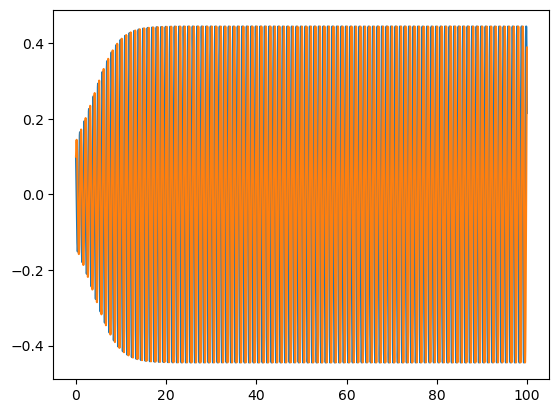

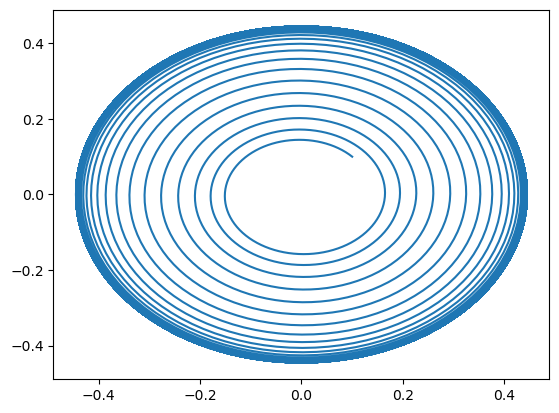

In [5]:
# Continuous Version

# zdot = z * (alpha + 1j * 2 * np.pi + beta1 * np.abs(z)**2) + F

import numpy as np
import matplotlib.pyplot as plt

# DISCRETIZE with Forward Euler
FS = 100
dt = 1/FS
DUR = 100
t = np.arange(0, DUR, dt)

z0 = 0.1 + 1j*0.1
z = np.zeros_like(t) + 1j * 0
z[0] = z0

# limit cycle: alpha positive, beta1 negative
alpha = 1
beta1 = -1

# damping oscillator: alpha negative, beta1 zero
alpha = -1
beta1 = 0

# Hopf Bifurcation: alpha zero, beta1 zero
alpha = 0
beta1 = -1


for n, tcurr in enumerate(t):
  if n < len(t) - 1:
    z[n+1] = z[n] +  dt * z[n] * (alpha + 1j * 2 * np.pi + beta1 * np.abs(z[n])**2) 

plt.plot(t,np.real(z))
plt.plot(t,np.imag(z))
plt.show()

plt.plot(np.real(z),np.imag(z))
plt.show()

In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# Core ODE and RK4
# ──────────────────────────────────────────────────────────────────────────────

def _rhs(z, x_t, freqs, alpha, r, beta1, beta2, epsilon):
    """
    Vectorised right-hand side of the GFNN ODE.

    z      : complex ndarray (n_freqs,)
    x_t    : float  — forcing value at current time step
    freqs  : float ndarray (n_freqs,)  — natural frequencies [Hz]
    """
    z2    = np.abs(z) ** 2
    z4    = z2 ** 2
    denom = 1.0 - epsilon * z2
    # Protect against singularity (|z|² → 1/ε)
    denom = np.where(np.abs(denom) < 1e-12,
                     np.sign(denom.real + 1e-30) * 1e-12, denom)

    nl = alpha + 1j * 2.0 * np.pi * r + beta1 * z2 + (epsilon * beta2 * z4) / denom
    return freqs * (z * nl + x_t)


def _rk4_step(z, x_n, x_half, x_n1, freqs, alpha, r, beta1, beta2, epsilon, dt):
    """Single RK4 step. x_half is the forcing interpolated at t + dt/2."""
    k1 = _rhs(z,              x_n,    freqs, alpha, r, beta1, beta2, epsilon)
    k2 = _rhs(z + 0.5*dt*k1, x_half, freqs, alpha, r, beta1, beta2, epsilon)
    k3 = _rhs(z + 0.5*dt*k2, x_half, freqs, alpha, r, beta1, beta2, epsilon)
    k4 = _rhs(z +     dt*k3, x_n1,   freqs, alpha, r, beta1, beta2, epsilon)
    return z + (dt / 6.0) * (k1 + 2.0*k2 + 2.0*k3 + k4)

In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# Public API
# ──────────────────────────────────────────────────────────────────────────────

def integrate_gfnn(
    x,
    freqs,
    fs=100.0,
    alpha=-0.1,
    r=1.0,
    beta1=-1.0,
    beta2=-1.0,
    epsilon=1.0,
    z0=None,
):
    """
    Integrate the GFNN ODE for a bank of oscillators driven by signal x.

    Parameters
    ----------
    x       : array-like (N,)
        Forcing signal (acoustic envelope) sampled at `fs` Hz.
    freqs   : array-like (n_freqs,)
        Natural frequencies of each oscillator in Hz (e.g. 0.1 – 30).
    fs      : float
        Sampling rate of x in Hz.  Default 100 Hz.
    alpha   : float
        Linear growth/damping term.
          α > 0 → limit-cycle oscillator (supercritical Hopf)
          α < 0 → damped, only responds while driven
    r       : float
        Sets the intrinsic rotation rate; usually 1.0.
    beta1   : float
        Cubic nonlinear coefficient (typically < 0 → saturation).
    beta2   : float
        Quintic nonlinear coefficient.
    epsilon : float
        Scaling of the higher-order rational term.
    z0      : array-like (n_freqs,) complex, optional
        Initial oscillator states.  Defaults to tiny random perturbations.

    Returns
    -------
    Z : ndarray (N, n_freqs), complex
        Oscillator responses z_i(t).
    t : ndarray (N,)
        Time axis in seconds.
    """
    x     = np.asarray(x,     dtype=float)
    freqs = np.asarray(freqs, dtype=float)

    N       = len(x)
    n_freqs = len(freqs)
    dt      = 1.0 / fs

    if z0 is None:
        rng = np.random.default_rng(0)
        z0  = (rng.standard_normal(n_freqs) * 1e-6
               + 1j * rng.standard_normal(n_freqs) * 1e-6)

    Z    = np.zeros((N, n_freqs), dtype=complex)
    Z[0] = np.asarray(z0, dtype=complex)
    z    = Z[0].copy()

    for n in range(N - 1):
        x_n    = x[n]
        x_n1   = x[n + 1]
        x_half = 0.5 * (x_n + x_n1)   # midpoint interpolation

        z = _rk4_step(z, x_n, x_half, x_n1,
                      freqs, alpha, r, beta1, beta2, epsilon, dt)
        Z[n + 1] = z

    t = np.arange(N) * dt
    return Z, t

In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# Visualisation / corroboration
# ──────────────────────────────────────────────────────────────────────────────

def plot_free_oscillation(freqs_to_show=(1.0, 5.0, 10.0), duration=10.0, fs=100.0,
                          alpha=0.1, r=1.0, beta1=-1.0, beta2=-1.0, epsilon=1.0):
    """
    Corroboration 1 — Free oscillation (x = 0).

    With α > 0 the orbit should spiral outward from the origin and settle
    on a limit cycle.  The predicted radius |z*| = √(−α/β₁) is overlaid.
    """
    N = int(duration * fs)
    x = np.zeros(N)

    ncols = len(freqs_to_show)
    fig, axes = plt.subplots(2, ncols, figsize=(5 * ncols, 7))
    if ncols == 1:
        axes = axes.reshape(2, 1)

    fig.suptitle(
        "Free Oscillation  (x = 0)  |  α={}, β₁={}, β₂={}, ε={}\n"
        "Limit-cycle radius: |z*| = √(−α/β₁)".format(alpha, beta1, beta2, epsilon),
        fontsize=12
    )

    for col, fi in enumerate(freqs_to_show):
        Z, t = integrate_gfnn(x, [fi], fs=fs, alpha=alpha, r=r,
                               beta1=beta1, beta2=beta2, epsilon=epsilon)
        z   = Z[:, 0]
        amp = np.abs(z)

        r_lc = np.sqrt(-alpha / beta1) if (alpha > 0 and beta1 < 0) else None

        # ── Time-domain amplitude
        ax_top = axes[0, col]
        ax_top.plot(t, amp, lw=0.8, color="steelblue")
        if r_lc is not None:
            ax_top.axhline(r_lc, color="tomato", ls="--", lw=1.4,
                           label=f"|z*| = {r_lc:.4f}")
            ax_top.legend(fontsize=8)
        ax_top.set_title(f"f = {fi} Hz", fontsize=10)
        ax_top.set_xlabel("t  [s]")
        ax_top.set_ylabel("|z(t)|")
        ax_top.set_ylim(bottom=0)

        # ── Phase portrait (colour = time)
        ax_bot = axes[1, col]
        n_pts  = len(z)
        colors = cm.viridis(np.linspace(0, 1, n_pts - 1))
        for k in range(n_pts - 1):
            ax_bot.plot(z[k:k+2].real, z[k:k+2].imag,
                        color=colors[k], lw=0.5, alpha=0.8)
        if r_lc is not None:
            theta = np.linspace(0, 2*np.pi, 400)
            ax_bot.plot(r_lc*np.cos(theta), r_lc*np.sin(theta),
                        "r--", lw=1.4, label="Predicted limit cycle")
            ax_bot.legend(fontsize=8)
        ax_bot.set_aspect("equal")
        ax_bot.set_xlabel("Re(z)")
        ax_bot.set_ylabel("Im(z)")
        ax_bot.set_title("Phase portrait  (colour = time)")

    sm = cm.ScalarMappable(cmap="viridis", norm=Normalize(0, duration))
    sm.set_array([])
    fig.colorbar(sm, ax=axes[1, :].tolist(), label="Time [s]", shrink=0.6)
    fig.subplots_adjust(top=0.88, hspace=0.45, wspace=0.35)
    return fig


def plot_forced_response(x, onset_times, freqs_subset, t, Z_subset):
    """
    Corroboration 2 — Driven response.

    Shows the forcing envelope + onset ticks, then the magnitude |z_i(t)|
    for a representative subset of oscillators.
    """
    n = len(freqs_subset)

    fig = plt.figure(figsize=(14, 3 + 2.2 * n))
    gs  = gridspec.GridSpec(2 + n, 1, hspace=0.6,
                            top=0.93, bottom=0.06, left=0.08, right=0.97)
    fig.suptitle("GFNN Forced Response  —  Envelope & Oscillator Magnitudes",
                 fontsize=12)

    ax0 = fig.add_subplot(gs[0])
    ax0.plot(t, x, lw=0.8, color="dimgray")
    ax0.set_ylabel("Envelope")
    ax0.set_title("Input signal (acoustic envelope)")
    ax0.set_xlim(t[0], t[-1])

    ax1 = fig.add_subplot(gs[1], sharex=ax0)
    ax1.vlines(onset_times, 0, 1, colors="darkorange", lw=1.0, alpha=0.8)
    ax1.set_ylabel("Onsets")
    ax1.set_ylim(-0.1, 1.6)
    ax1.set_yticks([])

    palette = cm.plasma(np.linspace(0.1, 0.9, n))
    for k, (fi, col) in enumerate(zip(freqs_subset, palette)):
        ax = fig.add_subplot(gs[2 + k], sharex=ax0)
        ax.plot(t, np.abs(Z_subset[:, k]), lw=0.8, color=col)
        ax.set_ylabel(f"|z|  {fi:.2f} Hz", fontsize=8)
        ax.set_xlim(t[0], t[-1])
        if k == n - 1:
            ax.set_xlabel("Time  [s]")

    return fig


def plot_scalogram(freqs, t, Z, log_scale=True):
    """
    Corroboration 3 — Time-frequency scalogram of |z_i(t)|.

    Shows which frequency bands are activated and when.
    """
    amp = np.abs(Z).T   # (n_freqs, N)

    fig, ax = plt.subplots(figsize=(14, 5))
    vmax = np.percentile(amp, 99)
    im   = ax.pcolormesh(t, freqs, amp, shading="auto",
                         cmap="magma", vmin=0, vmax=vmax)
    if log_scale and freqs[0] > 0:
        ax.set_yscale("log")
        ax.set_yticks(freqs[[0, len(freqs)//4, len(freqs)//2, 3*len(freqs)//4, -1]])
        ax.set_yticklabels([f"{f:.2f}" for f in
                             freqs[[0, len(freqs)//4, len(freqs)//2, 3*len(freqs)//4, -1]]])
    ax.set_xlabel("Time  [s]")
    ax.set_ylabel("Oscillator frequency  [Hz]")
    ax.set_title("GFNN Scalogram  —  |z_i(t)|")
    plt.colorbar(im, ax=ax, label="|z|")
    plt.tight_layout()
    return fig


def plot_numerical_stability(t, Z, freqs):
    """
    Corroboration 4 — Numerical stability.

    Total energy  Σ|z_i|²  should be bounded and smooth.
    Runaway growth would indicate integration failure.
    Also plots max amplitude per oscillator to check for outliers.
    """
    energy  = (np.abs(Z) ** 2).sum(axis=1)
    max_amp = np.abs(Z).max(axis=0)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
    fig.suptitle("Numerical Stability Checks", fontsize=12)

    ax1.plot(t, energy, lw=0.9, color="seagreen")
    ax1.set_xlabel("Time  [s]")
    ax1.set_ylabel("Σ |z_i|²")
    ax1.set_title("Total energy over time  (should be bounded and smooth)")

    ax2.semilogx(freqs, max_amp, "o-", ms=4, lw=1, color="steelblue")
    ax2.set_xlabel("Oscillator frequency  [Hz]")
    ax2.set_ylabel("max |z_i|  over time")
    ax2.set_title("Peak amplitude per oscillator  (frequency tuning curve)")

    fig.tight_layout()
    return fig

In [9]:
# ──────────────────────────────────────────────────────────────────────────────
# Demo
# ──────────────────────────────────────────────────────────────────────────────

def _make_demo_signals(fs=100.0, duration=20.0, base_ioi=0.5, n_events=35):
    """
    Synthesise surrogate acoustic features:
      onsets  : impulse train at irregular inter-onset intervals
      envelope: exponential-decay pulse at each onset
    """
    N   = int(duration * fs)
    rng = np.random.default_rng(42)

    iois   = base_ioi + rng.uniform(-0.12, 0.12, n_events)
    times  = np.cumsum(iois)
    times  = times[times < duration]

    onsets   = np.zeros(N)
    envelope = np.zeros(N)
    decay_s  = 0.12

    for ot in times:
        idx = int(ot * fs)
        if idx < N:
            onsets[idx] = 1.0
            length = min(int(decay_s * 5 * fs), N - idx)
            envelope[idx: idx + length] += np.exp(-np.arange(length) / (decay_s * fs))

    t = np.arange(N) / fs
    return onsets, envelope, t, times


def run_demo(output_dir=None, save_figs=False):
    """
    End-to-end demo with four corroboration figures.

    Parameters
    ----------
    output_dir : str or None
        Directory to save figures.  Defaults to the current working directory.
        Pass output_dir=False to skip saving altogether.
    save_figs  : bool
        Set False to only display figures without saving (useful in notebooks).
    """
    fs = 100.0

    print("Building demo acoustic features …")
    onsets, envelope, t, onset_times = _make_demo_signals(fs=fs, duration=20.0)

    # Oscillator bank: 0.1 – 10 Hz, 40 channels, log-spaced
    freqs = np.logspace(np.log10(0.1), np.log10(10.0), 40)

    gfnn_params = dict(
        fs      = fs,
        alpha   =  0.1,     # supercritical → limit-cycle oscillators
        r       =  1.0,
        beta1   = -1.0,
        beta2   = -1.0,
        epsilon =  1.0,
    )

    print(f"Integrating {len(freqs)} oscillators over {len(envelope)/fs:.0f} s …")        
    Z, t = integrate_gfnn(envelope, freqs, **gfnn_params)
    print(f"  Z shape: {Z.shape}")

    # Representative subset for forced-response plot
    idx_subset = [0, 8, 18, 28, 39]    
    freqs_sub  = freqs[idx_subset]
    Z_sub      = Z[:, idx_subset]

    print("Rendering corroboration figures …")
    figs = [
        ("gfnn_fig1_free_oscillation.png",
         plot_free_oscillation(freqs_to_show=(0.5, 2.0, 8.0), duration=30.0, fs=fs,
                               alpha=0.1, r=1.0, beta1=-1.0, beta2=-1.0, epsilon=1.0)),
        ("gfnn_fig2_forced_response.png",
         plot_forced_response(envelope, onset_times, freqs_sub, t, Z_sub)),
        ("gfnn_fig3_scalogram.png",
         plot_scalogram(freqs, t, Z)),
        ("gfnn_fig4_stability.png",
         plot_numerical_stability(t, Z, freqs)),
    ]

    if save_figs:
        out = output_dir if output_dir else os.getcwd()
        os.makedirs(out, exist_ok=True)
        for fname, fig in figs:
            path = os.path.join(out, fname)
            fig.savefig(path, dpi=150, bbox_inches="tight")
            print(f"  Saved {path}")

    plt.show()
    print("Done.")
    return Z, t, freqs

In [10]:
def run_demo_with_events(events, output_dir=None, save_figs=False):
    """
    End-to-end demo using acoustic envelopes from the events table.
    
    Parameters
    ----------
    events : eelbrain.Dataset
        Events table containing 'envelope' and 'onsets' NDVars.
    output_dir : str or None
        Directory to save figures.
    save_figs : bool
        Set False to only display figures without saving.
    """
    fs = 100.0
    
    print("Extracting acoustic features from events table …")
    
    # Concatenate all trial envelopes into a single continuous signal
    envelope_list = events['envelope']
    onsets_list = events['onsets']
    
    # Flatten to 1D arrays
    envelope = np.concatenate([np.asarray(env) for env in envelope_list])
    onsets = np.concatenate([np.asarray(ons) for ons in onsets_list])
    
    # Find onset times (where onsets > 0)
    onset_times = np.where(onsets > 0)[0] / fs
    
    t = np.arange(len(envelope)) / fs
    
    print(f"  Envelope length: {len(envelope)} samples ({len(envelope)/fs:.1f} s)")
    print(f"  Detected {len(onset_times)} onsets")
    
    # Oscillator bank: 0.1 – 10 Hz, 40 channels, log-spaced
    freqs = np.logspace(np.log10(0.1), np.log10(10.0), 40)
    
    gfnn_params = dict(
        fs      = fs,
        alpha   =  0.1,
        r       =  1.0,
        beta1   = -1.0,
        beta2   = -1.0,
        epsilon =  1.0,
    )
    
    print(f"Integrating {len(freqs)} oscillators …")
    Z, t = integrate_gfnn(envelope, freqs, **gfnn_params)
    print(f"  Z shape: {Z.shape}")
    
    # Representative subset for forced-response plot
    idx_subset = [0, 8, 18, 28, 39]
    freqs_sub = freqs[idx_subset]
    Z_sub = Z[:, idx_subset]
    
    print("Rendering corroboration figures …")
    figs = [
        ("gfnn_fig1_free_oscillation.png",
         plot_free_oscillation(freqs_to_show=(0.5, 2.0, 8.0), duration=30.0, fs=fs,
                               alpha=0.1, r=1.0, beta1=-1.0, beta2=-1.0, epsilon=1.0)),
        ("gfnn_fig2_forced_response.png",
         plot_forced_response(envelope, onset_times, freqs_sub, t, Z_sub)),
        ("gfnn_fig3_scalogram.png",
         plot_scalogram(freqs, t, Z)),
        ("gfnn_fig4_stability.png",
         plot_numerical_stability(t, Z, freqs)),
    ]
    
    if save_figs:
        out = output_dir if output_dir else os.getcwd()
        os.makedirs(out, exist_ok=True)
        for fname, fig in figs:
            path = os.path.join(out, fname)
            fig.savefig(path, dpi=150, bbox_inches="tight")
            print(f"  Saved {path}")
    
    plt.show()
    print("Done.")
    return Z, t, freqs

In [11]:
onsets, envelope, t, times = _make_demo_signals()
print("Onsets", len(onsets), type(onsets))
print("Envelope", len(envelope), type(envelope))
print("t", len(t), type(t))
print("Times", len(times), type(times))

Onsets 2000 <class 'numpy.ndarray'>
Envelope 2000 <class 'numpy.ndarray'>
t 2000 <class 'numpy.ndarray'>
Times 35 <class 'numpy.ndarray'>


Extracting acoustic features from events table …
  Envelope length: 477486 samples (4774.9 s)
  Detected 112899 onsets
Integrating 40 oscillators …


/var/folders/r4/z65_5ryn59z3_3lyzgvxdcm40000gn/T/ipykernel_47633/507225536.py:14: RuntimeWarning: overflow encountered in square
  z4    = z2 ** 2
/var/folders/r4/z65_5ryn59z3_3lyzgvxdcm40000gn/T/ipykernel_47633/507225536.py:21: RuntimeWarning: invalid value encountered in multiply
  return freqs * (z * nl + x_t)
/var/folders/r4/z65_5ryn59z3_3lyzgvxdcm40000gn/T/ipykernel_47633/507225536.py:13: RuntimeWarning: overflow encountered in square
  z2    = np.abs(z) ** 2
/var/folders/r4/z65_5ryn59z3_3lyzgvxdcm40000gn/T/ipykernel_47633/507225536.py:20: RuntimeWarning: invalid value encountered in divide
  nl = alpha + 1j * 2.0 * np.pi * r + beta1 * z2 + (epsilon * beta2 * z4) / denom


  Z shape: (477486, 40)
Rendering corroboration figures …


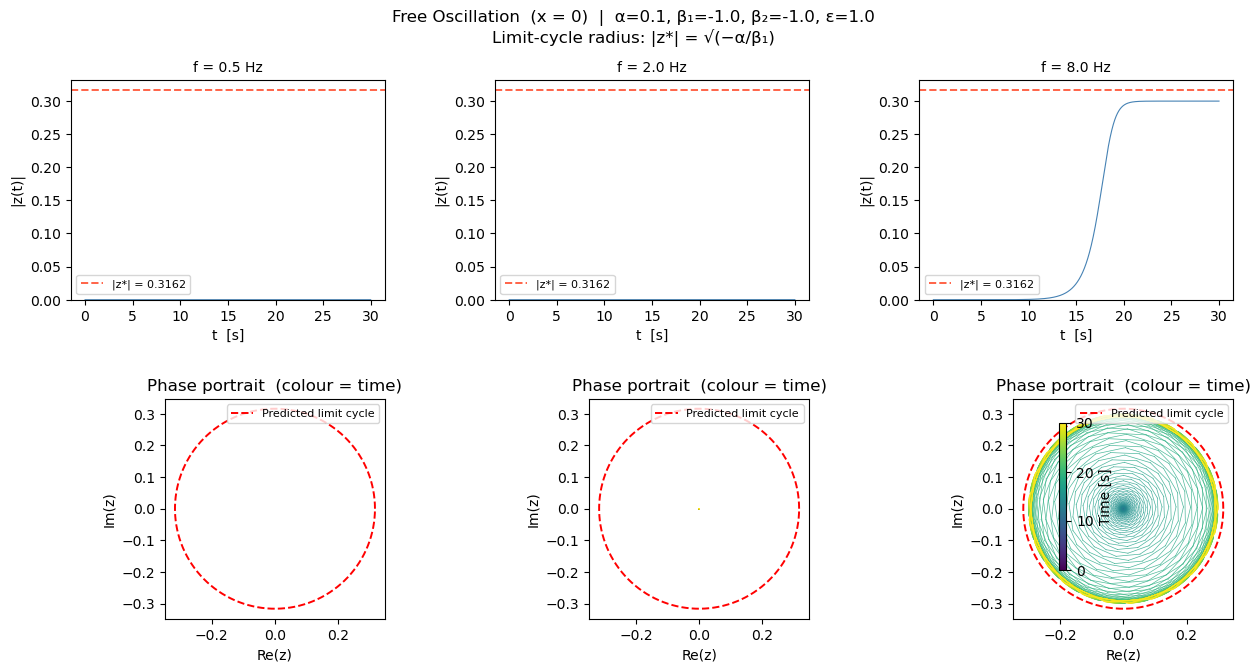

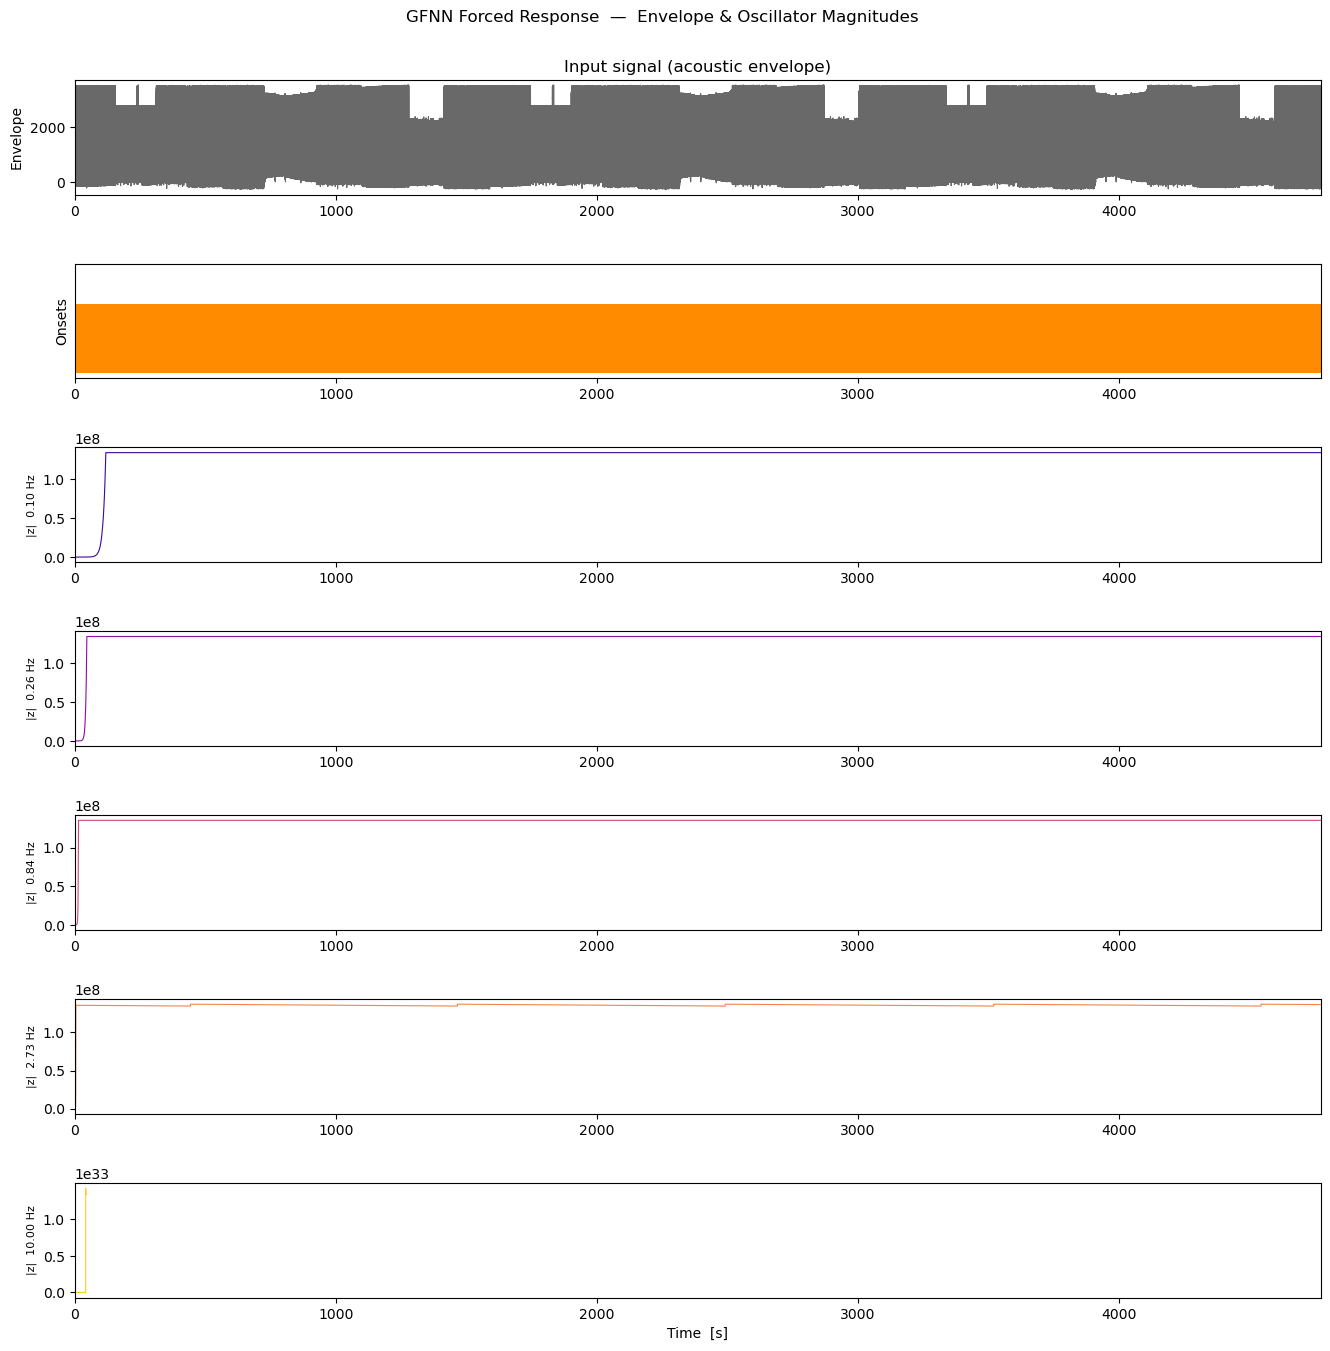

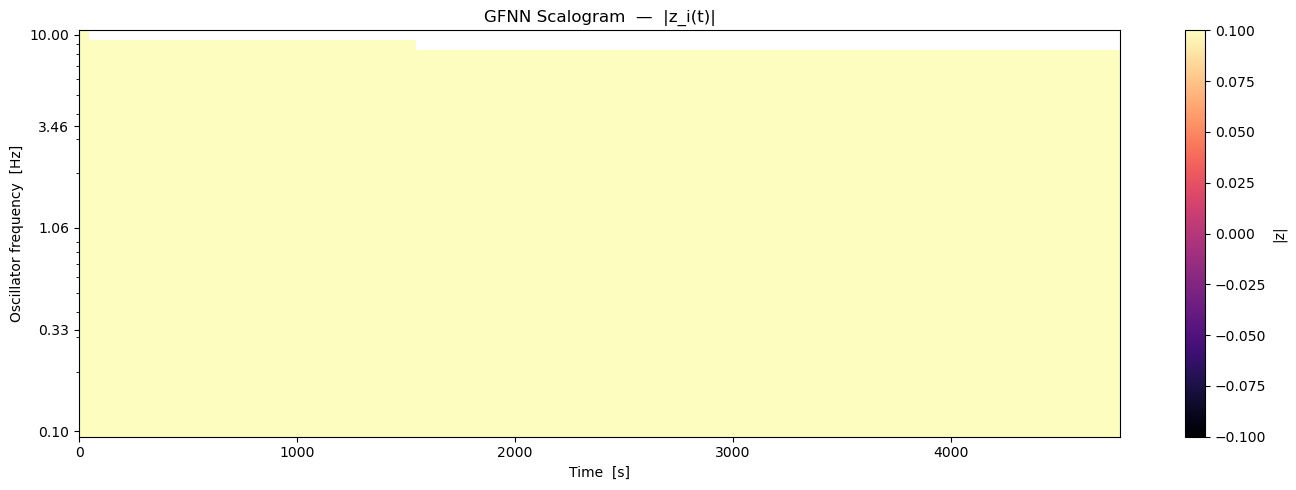

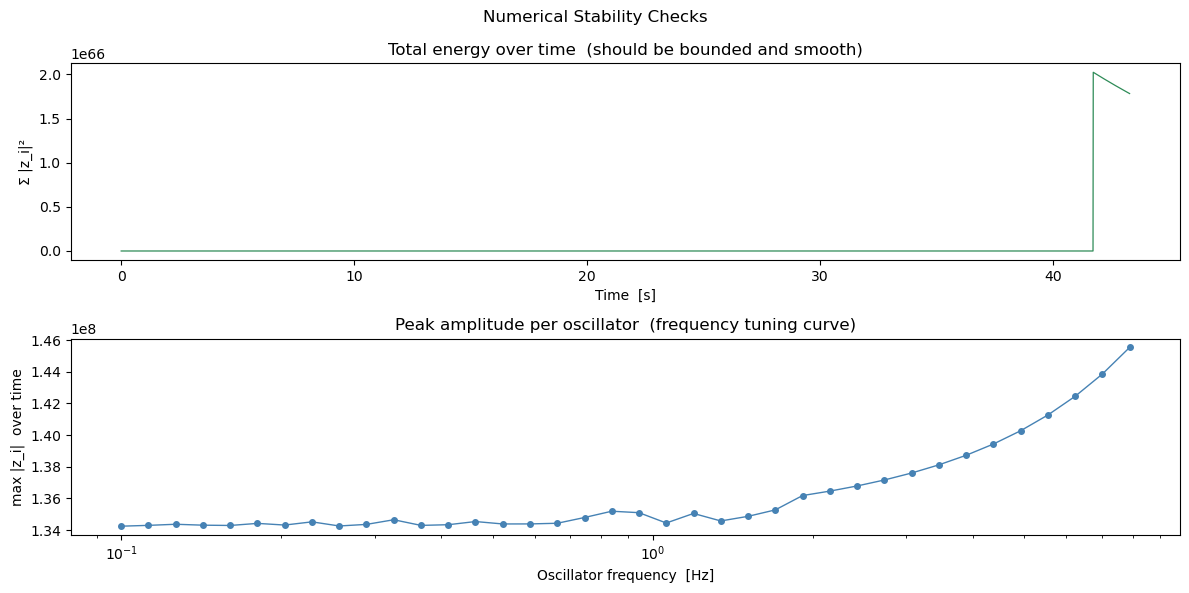

Done.


In [12]:
if __name__ == "__main__":
    run_demo_with_events(events)

In [16]:
def run_gfnn_per_trial(events, output_dir=None, save_figs=False):
    """
    Run GFNN on each trial independently and add results to events table
    as eelbrain NDVars with (time, freq) dimensions.
    Four NDVar columns: amplitude, phase, real, imaginary.
    """
    fs = 100.0
    n_trials = 30
    
    print(f"Processing {n_trials} trials independently …")
    
    # Oscillator bank: 0.1 – 10 Hz, 40 channels, log-spaced
    freqs = np.logspace(np.log10(0.1), np.log10(8.0), 40)
    freq_dim = eelbrain.Scalar('frequency', freqs, unit='Hz')
    
    gfnn_params = dict(
        fs      = fs,
        alpha   =  0.1,
        r       =  1.0,
        beta1   = -1.0,
        beta2   = -1.0,
        epsilon =  1.0,
    )
    
    gfnn_amp_ndvars  = []
    gfnn_phase_ndvars = []
    gfnn_real_ndvars  = []
    gfnn_imag_ndvars  = []
    
    for trial_idx in range(n_trials):
        envelope = np.asarray(events['envelope'][trial_idx])
        onsets   = np.asarray(events['onsets'][trial_idx])
        
        # Run GFNN — Z shape is (n_times, n_freqs)
        Z, t = integrate_gfnn(envelope, freqs, **gfnn_params)
        
        # Reuse the same time axis as the envelope for this trial
        time_dim = events['envelope'][trial_idx].time
        
        # Sanity check
        if Z.shape[0] != time_dim.nsamples:
            raise ValueError(
                f"Trial {trial_idx+1}: Z n_times={Z.shape[0]} "
                f"!= envelope n_times={time_dim.nsamples}. "
                f"Check GFNN output length."
            )
        
        # Decompose complex Z into 4 representations
        Z_amp   = np.abs(Z)       # instantaneous amplitude, shape (n_times, n_freqs)
        Z_phase = np.angle(Z)     # instantaneous phase in radians
        Z_real  = np.real(Z)      # real part
        Z_imag  = np.imag(Z)      # imaginary part
        
        def make_ndvar(data, name):
            return eelbrain.NDVar(data, dims=(time_dim, freq_dim), name=name)
        
        gfnn_amp_ndvars.append(make_ndvar(Z_amp,   'gfnn_amplitude'))
        gfnn_phase_ndvars.append(make_ndvar(Z_phase, 'gfnn_phase'))
        gfnn_real_ndvars.append(make_ndvar(Z_real,  'gfnn_real'))
        gfnn_imag_ndvars.append(make_ndvar(Z_imag,  'gfnn_imaginary'))
        
        print(f"  Trial {trial_idx+1:2d}/{n_trials}  |  "
              f"Z shape: {Z.shape}  |  "
              f"amp range: [{Z_amp.min():.3f}, {Z_amp.max():.3f}]  |  "
              f"phase range: [{Z_phase.min():.3f}, {Z_phase.max():.3f}]")
    
    events['gfnn_amplitude']  = gfnn_amp_ndvars
    events['gfnn_phase']      = gfnn_phase_ndvars
    events['gfnn_real']       = gfnn_real_ndvars
    events['gfnn_imaginary']  = gfnn_imag_ndvars
    
    print(f"\n✓ Added 4 GFNN columns to events table "
          f"(each: n_times × {len(freqs)} freqs per trial)")
    print(f"  Columns: gfnn_amplitude, gfnn_phase, gfnn_real, gfnn_imaginary")
    
    return events, freqs

In [17]:
events, freqs = run_gfnn_per_trial(events, save_figs=False)
events

Processing 30 trials independently …
  Trial  1/30  |  Z shape: (15804, 40)  |  amp range: [0.000, 145739116.706]  |  phase range: [-3.142, 3.142]
  Trial  2/30  |  Z shape: (15310, 40)  |  amp range: [0.000, 145738947.006]  |  phase range: [-3.142, 3.142]
  Trial  3/30  |  Z shape: (11929, 40)  |  amp range: [0.000, 145739701.499]  |  phase range: [-3.142, 3.142]
  Trial  4/30  |  Z shape: (13450, 40)  |  amp range: [0.000, 145739958.748]  |  phase range: [-3.142, 3.142]
  Trial  5/30  |  Z shape: (16473, 40)  |  amp range: [0.000, 145738876.371]  |  phase range: [-3.142, 3.142]
  Trial  6/30  |  Z shape: (19831, 40)  |  amp range: [0.000, 145739937.632]  |  phase range: [-3.142, 3.142]
  Trial  7/30  |  Z shape: (17217, 40)  |  amp range: [0.000, 145739645.275]  |  phase range: [-3.142, 3.142]
  Trial  8/30  |  Z shape: (18121, 40)  |  amp range: [0.000, 145739599.687]  |  phase range: [-3.142, 3.142]
  Trial  9/30  |  Z shape: (13317, 40)  |  amp range: [0.000, 145735182.078]  |  ph

#,i_start,trigger,event,envelope,onsets,duration,eeg,gfnn_amplitude,gfnn_phase,gfnn_real,gfnn_imaginary
0,1,1,1,<NDVar '1.wa...,<NDVar '1.wa...,158.04,<NDVar: 64 s...,<NDVar 'gfnn...,<NDVar 'gfnn...,<NDVar 'gfnn...,<NDVar 'gfnn...
1,15992,2,2,<NDVar '2.wa...,<NDVar '2.wa...,153.1,<NDVar: 64 s...,<NDVar 'gfnn...,<NDVar 'gfnn...,<NDVar 'gfnn...,<NDVar 'gfnn...
2,31495,3,3,<NDVar '3.wa...,<NDVar '3.wa...,119.29,<NDVar: 64 s...,<NDVar 'gfnn...,<NDVar 'gfnn...,<NDVar 'gfnn...,<NDVar 'gfnn...
3,43610,4,4,<NDVar '4.wa...,<NDVar '4.wa...,134.5,<NDVar: 64 s...,<NDVar 'gfnn...,<NDVar 'gfnn...,<NDVar 'gfnn...,<NDVar 'gfnn...
4,57289,5,5,<NDVar '5.wa...,<NDVar '5.wa...,164.73,<NDVar: 64 s...,<NDVar 'gfnn...,<NDVar 'gfnn...,<NDVar 'gfnn...,<NDVar 'gfnn...
5,73962,6,6,<NDVar '6.wa...,<NDVar '6.wa...,198.31,<NDVar: 64 s...,<NDVar 'gfnn...,<NDVar 'gfnn...,<NDVar 'gfnn...,<NDVar 'gfnn...
6,93992,7,7,<NDVar '7.wa...,<NDVar '7.wa...,172.17,<NDVar: 64 s...,<NDVar 'gfnn...,<NDVar 'gfnn...,<NDVar 'gfnn...,<NDVar 'gfnn...
7,111409,8,8,<NDVar '8.wa...,<NDVar '8.wa...,181.21,<NDVar: 64 s...,<NDVar 'gfnn...,<NDVar 'gfnn...,<NDVar 'gfnn...,<NDVar 'gfnn...
8,129730,9,9,<NDVar '9.wa...,<NDVar '9.wa...,133.17,<NDVar: 64 s...,<NDVar 'gfnn...,<NDVar 'gfnn...,<NDVar 'gfnn...,<NDVar 'gfnn...
9,143247,10,10,<NDVar '10.w...,<NDVar '10.w...,177.1,<NDVar: 64 s...,<NDVar 'gfnn...,<NDVar 'gfnn...,<NDVar 'gfnn...,<NDVar 'gfnn...


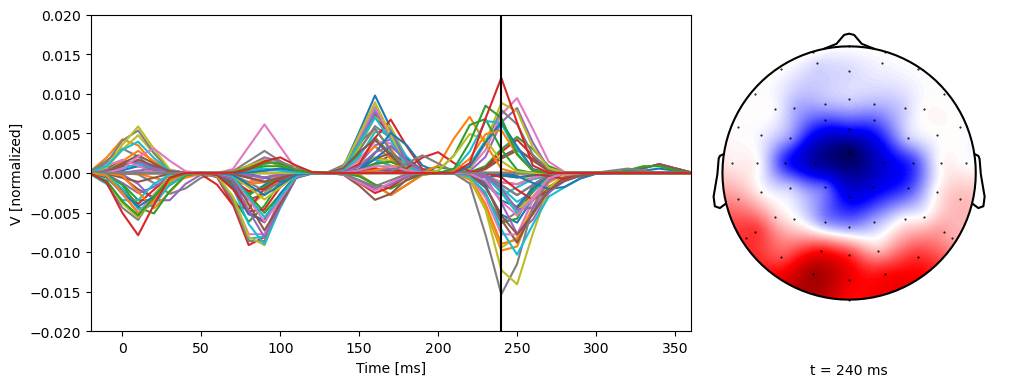

In [ ]:
variables = [
    'envelope',
    'onsets',
    'gfnn_amplitude',
    'gfnn_phase',
    'gfnn_real',
    'gfnn_imaginary'
]

# Estimate the TRF: boosting(y, x, tstart, tstop[, scale_data, ...])
# trf = eelbrain.boosting('eeg', variables, 0, 0.350, data=events, basis=0.050, partitions=4, error='l1')

# t = trf.h[0].std('sensor').argmax('time')
# p = eelbrain.plot.TopoButterfly(trf.h[0], t=t, w=10, h=4, clip='circle')


In [19]:
trf = eelbrain.boosting('eeg', variables,  -0.150, 0.750, data=events, basis=0.050, partitions=4, error='l1')

# Estimate the predicted power
trf_cv = eelbrain.boosting('eeg', variables,  -0.150, 0.750, data=events, basis=0.050, partitions=4, error='l1')

# Train envelope decoder
decoder = eelbrain.boosting('envelope', 'eeg', -0.600, 0.200, data=events, partitions=4, basis=0.05, error='l1')

# Train onsets decoder
decoder_onsets = eelbrain.boosting('onsets', 'eeg', -0.600, 0.200, data=events, partitions=4, basis=0.05, error='l1')

# Create the data structure for one subject and one band
# trf and trf_cv are saved for future research; decoder, decoder_onsets, and trials are used in this paper

all_data = {
    'trf': trf,
    'trf_cv': trf_cv,
    'decoder': decoder,
    'decoder_onsets': decoder_onsets,
    'trials': {}
}

In [29]:
# Loop through all trials
for trial_num in range(30):
    
    # Normalize the EEG      
    eeg_one_event = events[trial_num, 'eeg'] / decoder.x_scale
    # Predict the envelope by convolving the decoder with the EEG
    y_pred = eelbrain.convolve(decoder.h, eeg_one_event, name='predicted envelope')

    # Normalize trial envelope and compute correlation with prediction
    y = events[trial_num, 'envelope']
    y = y - decoder.y_mean
    y /= decoder.y_scale / y_pred.std()
    y.name = 'envelope'
    r = eelbrain.correlation_coefficient(y, y_pred)
    
    # Normalize the EEG      
    eeg_one_event_onsets = events[trial_num, 'eeg'] / decoder_onsets.x_scale
    # Predict the onsets by convolving the decoder with the EEG
    y_pred_onsets = eelbrain.convolve(decoder_onsets.h, eeg_one_event_onsets, name='predicted onsets')

    # Normalize trial onsets and compute correlation with prediction
    y_onsets = events[trial_num, 'onsets']
    y_onsets = y_onsets - decoder_onsets.y_mean
    y_onsets /= decoder_onsets.y_scale / y_pred_onsets.std()
    y_onsets.name = 'onsets'
    r_onsets = eelbrain.correlation_coefficient(y_onsets, y_pred_onsets)
    
    # Store trial data
    trial_data = {
        'y_pred': y_pred,
        'y': y,
        'r': r,
        'y_pred_onsets': y_pred_onsets,
        'y_onsets': y_onsets,
        'r_onsets': r_onsets
    }
    
    # Add to trials dictionary
    all_data['trials'][f'trial{trial_num}'] = trial_data
    
    print(f"Processed trial {trial_num}: envelope r={r}, onsets r={r_onsets}")


Processed trial 0: envelope r=0.21805002698204184, onsets r=0.10168218622372135
Processed trial 1: envelope r=0.1816863531641451, onsets r=0.10165200398873167
Processed trial 2: envelope r=0.11469829640632866, onsets r=0.035926002952197895
Processed trial 3: envelope r=0.14729224388514664, onsets r=0.030258677013563783
Processed trial 4: envelope r=0.07687335956384622, onsets r=0.028250359642446377
Processed trial 5: envelope r=0.10628076360804277, onsets r=0.04405096058366951
Processed trial 6: envelope r=0.20374615895943013, onsets r=0.05630853710737922
Processed trial 7: envelope r=0.12998018908913395, onsets r=0.03395349136972475
Processed trial 8: envelope r=0.13134234273980244, onsets r=0.06400249961619883
Processed trial 9: envelope r=0.16383753080670757, onsets r=0.05210483399753327
Processed trial 10: envelope r=0.29297251684340764, onsets r=0.16304641860078445
Processed trial 11: envelope r=0.24585985639467234, onsets r=0.15052105930862977
Processed trial 12: envelope r=0.090

In [ ]:
from datetime import date

SAVE_DIR = f'pickles_{date.today()}'

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

filename = os.path.join(SAVE_DIR, f'{SUBJECT}_{variables}_acoustic_music_data.pkl')
        
eelbrain.save.pickle(all_data, filename)